In [25]:
import sys
sys.path.append('../../scripts')
import burau_enchanced as lmp
import free_scripts as bf
from itertools import product
import numpy as np 
import matplotlib.pyplot as plt
import json
import sys
from multiprocessing import freeze_support


 

if __name__ == '__main__':
    freeze_support()
    def get_beans(invariant_dictionary):
        beans = [0]*len(invariant_dictionary)
        for key,value in invariant_dictionary.items():
            beans[key] = key
        beans = [x for x in beans if invariant_dictionary[x] != 0]
        return beans
   
    mod = 2
    n = 10
    symbol_to_matrix = {
        "A": lmp.A,
        "B": lmp.B,
        "a": lmp.a,
        "b": lmp.b
    }
    a = bf.calculate_products(symbol_to_matrix,n-1)
    modu = {key: value.convert_to_modulo(mod) for key, value in a.items()}
    matrices_mod = {
        "A": lmp.A.convert_to_modulo(mod),
        "B": lmp.B.convert_to_modulo(mod),
        "a": lmp.a.convert_to_modulo(mod),
        "b": lmp.b.convert_to_modulo(mod)
    }
    b = {key: value for key, value in modu.items() if len(key) == n}  
    c = b
    a.clear()

    beans_for_iter = []
    good_words = []
    for i in range(50):
        tier_percentages = [1,1,1]
        remaining_percentage = 0
        min_num = 50000
        max_num = 100000
        c = bf.tiered_sampling(c,tier_percentages,remaining_percentage,min_num,max_num)
        beans_for_iter.append(get_beans(bf.get_invariant_picture(c,bf.largest_power_range)))
        c = bf.extend_in_all_ways_p(matrices_mod,c,1)

        print(len(next(iter(c))),bf.min_invariant_in_array(c,bf.largest_power_range))
        good_words.extend(bf.min_invariant_in_array(c,bf.largest_power_range)[2])

100%|██████████| 9/9 [00:17<00:00,  1.99s/it]


11 (4, 0, [])
12 (4, 0, [])
13 (4, 0, [])
14 (4, 0, [])
15 (5, 0, [])
16 (4, 0, [])
17 (3, 0, [])
18 (4, 0, [])
19 (4, 0, [])
20 (4, 0, [])
21 (4, 0, [])
22 (4, 0, [])
23 (3, 0, [])
24 (4, 0, [])
25 (3, 0, [])
26 (4, 0, [])
27 (3, 0, [])
28 (3, 0, [])
29 (2, 0, [])
30 (2, 0, [])
31 (1, 0, [])
32 (0, 16, ['ABBBABaaBaaaaaBaBAAABAbbAbbbbbAb', 'AbbbAbaabaaaaababAAAbABBABBBBBAB', 'BAAABAbbAbbbbbAbABBBABaaBaaaaaBa', 'BaaaBabbabbbbbabaBBBaBAABAAAAABA', 'aBBBaBAABAAAAABABaaaBabbabbbbbab', 'abbbabAAbAAAAAbAbaaabaBBaBBBBBaB', 'bAAAbABBABBBBBABAbbbAbaabaaaaaba', 'baaabaBBaBBBBBaBabbbabAAbAAAAAbA', 'BABBBBBABBAbAAAbabaaaaabaabAbbbA', 'babbbbbabbaBaaaBABAAAAABAABaBBBa', 'BaBBBBBaBBabaaabAbAAAAAbAAbabbba', 'ABAAAAABAABaBBBababbbbbabbaBaaaB', 'AbAAAAAbAAbabbbaBaBBBBBaBBabaaab', 'aBaaaaaBaaBABBBAbAbbbbbAbbABAAAB', 'bAbbbbbAbbABAAABaBaaaaaBaaBABBBA', 'abaaaaabaabAbbbABABBBBBABBAbAAAb'])
33 (1, 0, [])
34 (0, 471, ['AABAAbAAAbAAbAAbAAAbAABAAABAABAABA', 'AAbAABAAABAABAABAAABAAbAAAbAAbAAbA', 'BBABBaBBBaBBa

In [30]:
print(good_words)
for word in good_words:
    history_beans = []
    for i in range(n,len(word)+1):
        print(bf.largest_power_range_word(matrices_mod,word[:i]))
        history_beans.append(beans_for_iter[i-n].index(bf.largest_power_range_word(matrices_mod,word[:i]))+1)
    print(f"Word: {word} \n Beans history:{history_beans}")
    break
    

['ABBBABaaBaaaaaBaBAAABAbbAbbbbbAb', 'AbbbAbaabaaaaababAAAbABBABBBBBAB', 'BAAABAbbAbbbbbAbABBBABaaBaaaaaBa', 'BaaaBabbabbbbbabaBBBaBAABAAAAABA', 'aBBBaBAABAAAAABABaaaBabbabbbbbab', 'abbbabAAbAAAAAbAbaaabaBBaBBBBBaB', 'bAAAbABBABBBBBABAbbbAbaabaaaaaba', 'baaabaBBaBBBBBaBabbbabAAbAAAAAbA', 'BABBBBBABBAbAAAbabaaaaabaabAbbbA', 'babbbbbabbaBaaaBABAAAAABAABaBBBa', 'BaBBBBBaBBabaaabAbAAAAAbAAbabbba', 'ABAAAAABAABaBBBababbbbbabbaBaaaB', 'AbAAAAAbAAbabbbaBaBBBBBaBBabaaab', 'aBaaaaaBaaBABBBAbAbbbbbAbbABAAAB', 'bAbbbbbAbbABAAABaBaaaaaBaaBABBBA', 'abaaaaabaabAbbbABABBBBBABBAbAAAb', 'AABAAbAAAbAAbAAbAAAbAABAAABAABAABA', 'AAbAABAAABAABAABAAABAAbAAAbAAbAAbA', 'BBABBaBBBaBBaBBaBBBaBBABBBABBABBAB', 'BBaBBABBBABBABBABBBABBaBBBaBBaBBaB', 'aaBaabaaabaabaabaaabaaBaaaBaaBaaBa', 'aabaaBaaaBaaBaaBaaaBaabaaabaabaaba', 'bbAbbabbbabbabbabbbabbAbbbAbbAbbAb', 'bbabbAbbbAbbAbbAbbbAbbabbbabbabbab', 'ABAAAABAAABAAABAAAABAAbAAbAbAbAAbA', 'AbAAAAbAAAbAAAbAAAAbAABAABABABAABA', 'BABBBBABBBABBBABBBBABBaBBaBaBaBBaB', 'BaBB

Running with smaller k but bigger number of beans

In [32]:
import sys
sys.path.append('../../scripts')
import burau_enchanced as lmp
import free_scripts as bf
from itertools import product
import numpy as np 
import matplotlib.pyplot as plt
import json
import sys
from multiprocessing import freeze_support


 

if __name__ == '__main__':
    freeze_support()
    def get_beans(invariant_dictionary):
        beans = [0]*len(invariant_dictionary)
        for key,value in invariant_dictionary.items():
            beans[key] = key
        beans = [x for x in beans if invariant_dictionary[x] != 0]
        return beans
   
    mod = 3
    n = 10
    symbol_to_matrix = {
        "A": lmp.A,
        "B": lmp.B,
        "a": lmp.a,
        "b": lmp.b
    }
    a = bf.calculate_products(symbol_to_matrix,n-1)
    modu = {key: value.convert_to_modulo(mod) for key, value in a.items()}
    matrices_mod = {
        "A": lmp.A.convert_to_modulo(mod),
        "B": lmp.B.convert_to_modulo(mod),
        "a": lmp.a.convert_to_modulo(mod),
        "b": lmp.b.convert_to_modulo(mod)
    }
    b = {key: value for key, value in modu.items() if len(key) == n}  
    c = b
    a.clear()

    beans_for_iter_mod3 = []
    good_words_mod3 = []
    for i in range(340):
        tier_percentages = [1,1,1]
        remaining_percentage = 0
        min_num = 20000
        max_num = 40000
        c = bf.tiered_sampling(c,tier_percentages,remaining_percentage,min_num,max_num)
        beans_for_iter.append(get_beans(bf.get_invariant_picture(c,bf.largest_power_range)))
        c = bf.extend_in_all_ways_p(matrices_mod,c,1)

        print(len(next(iter(c))),bf.min_invariant_in_array(c,bf.largest_power_range))
        good_words.extend(bf.min_invariant_in_array(c,bf.largest_power_range)[2])

100%|██████████| 9/9 [00:17<00:00,  1.99s/it]


11 (4, 0, [])
12 (4, 0, [])
13 (4, 0, [])
14 (4, 0, [])
15 (5, 0, [])
16 (5, 0, [])
17 (4, 0, [])
18 (5, 0, [])
19 (5, 0, [])
20 (5, 0, [])
21 (5, 0, [])
22 (5, 0, [])
23 (5, 0, [])
24 (5, 0, [])
25 (5, 0, [])
26 (5, 0, [])
27 (5, 0, [])
28 (5, 0, [])
29 (5, 0, [])
30 (5, 0, [])
31 (5, 0, [])
32 (6, 0, [])
33 (6, 0, [])
34 (5, 0, [])
35 (6, 0, [])
36 (6, 0, [])
37 (6, 0, [])
38 (6, 0, [])
39 (6, 0, [])
40 (6, 0, [])
41 (5, 0, [])
42 (6, 0, [])
43 (6, 0, [])
44 (6, 0, [])
45 (6, 0, [])
46 (6, 0, [])
47 (6, 0, [])
48 (6, 0, [])
49 (6, 0, [])
50 (6, 0, [])
51 (6, 0, [])
52 (6, 0, [])
53 (6, 0, [])
54 (6, 0, [])
55 (6, 0, [])
56 (6, 0, [])
57 (5, 0, [])
58 (6, 0, [])
59 (6, 0, [])
60 (6, 0, [])
61 (6, 0, [])
62 (6, 0, [])
63 (6, 0, [])
64 (5, 0, [])
65 (6, 0, [])
66 (6, 0, [])
67 (7, 0, [])
68 (7, 0, [])
69 (6, 0, [])
70 (6, 0, [])
71 (5, 0, [])
72 (6, 0, [])
73 (7, 0, [])
74 (6, 0, [])
75 (6, 0, [])
76 (7, 0, [])
77 (7, 0, [])
78 (7, 0, [])
79 (7, 0, [])
80 (7, 0, [])
81 (7, 0, [])
82 (6,

In [ ]:

history_beans = []
for i in range(n,len(word)+1):
    print(bf.largest_power_range_word(matrices_mod,word[:i]))
    history_beans.append(beans_for_iter[i-n+100].index(bf.largest_power_range_word(matrices_mod,word[:i]))+1)
print(f"Word: {word} \n Beans history:{history_beans}")


440
[[4, 5, 6, 7, 8], [4, 5, 6, 7, 8], [4, 5, 6, 7, 8], [4, 5, 6, 7, 8], [4, 5, 6, 7, 8], [5, 6, 7, 8], [4, 5, 6, 7, 8], [3, 5, 6, 7, 8], [4, 5, 6, 7, 8], [4, 5, 6, 7, 8], [4, 5, 6, 7, 8], [4, 5, 6, 7, 8], [4, 5, 6, 7, 8], [3, 4, 5, 6, 7], [4, 5, 6, 7], [3, 4, 5, 6, 7], [4, 5, 6, 7], [3, 4, 5, 6, 7], [3, 4, 5, 6, 7], [2, 3, 4, 5, 6, 7], [2, 3, 4, 5, 6, 7], [1, 2, 3, 4, 5, 6, 7], [0, 2, 3, 4, 5, 6], [1, 2, 3, 4, 5, 6], [0, 2, 3, 4, 5, 6], [1, 2, 3, 4, 5], [0, 2, 3, 4, 5], [1, 2, 3, 4, 5], [0, 2, 3, 4], [1, 2, 3, 4], [0, 2, 3, 4], [1, 2, 3, 4], [0, 2, 3, 4], [1, 2, 3, 4], [0, 2, 3, 4], [1, 2, 3, 4], [0, 2, 3, 4], [1, 2, 3, 4], [2, 3, 4], [2, 3, 4], [3, 4, 5], [3, 4, 5], [3, 4, 5], [3, 4, 5], [4, 5, 6], [4, 5, 6], [4, 5, 6], [3, 4, 5], [4, 5, 6], [3, 4, 5, 6], [4, 5, 6, 7], [4, 5, 6, 7], [4, 5, 6, 7], [4, 5, 6, 7], [4, 5, 6, 7], [5, 6, 7], [5, 6, 7], [4, 5, 6, 7], [5, 6, 7, 8], [5, 6, 7, 8], [5, 6, 7, 8], [5, 6, 7, 8], [5, 6, 7, 8], [5, 6, 7, 8], [5, 6, 7, 8], [5, 6, 7, 8], [5, 6, 7, 8], 

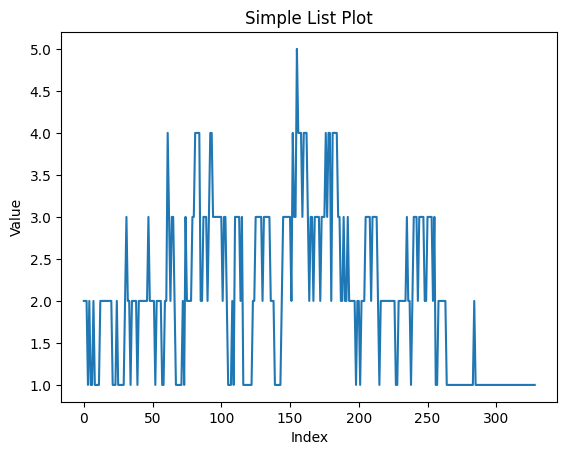

In [43]:
plt.plot(history_beans)
plt.title("Simple List Plot")
plt.xlabel("Index")
plt.ylabel("Value")
plt.show()